# Matchstick Equation Environment Demo

This notebook demonstrates the Matchstick Equation environment where you move matchsticks to fix equations.

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import display
from PIL import Image

## 1. Create and Inspect Environment (Easy)

In [2]:
env = gym.make("matchstick_equation/easy", seed=42)
print(f"Break moves allowed: {env.unwrapped.break_moves}")
print(f"Action Space: {env.action_space}")
print(f"Available actions: {env.action_space.get_function_names()}")

Break moves allowed: 1
Action Space: FuncConditional(['move', 'undo', 'stop'])
Available actions: ['move', 'undo', 'stop']


## 2. Reset and View Initial State

Observation shape: (80, 300, 3)
Info: {'equation': '77+55=742', 'is_correct': False, 'max_steps': 1000, 'history_depth': 1, 'current_moves': 0, 'env_feedback': None}


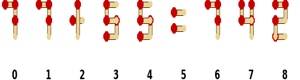


Task: Fix the equation by moving matchsticks

Task Prompt:
You see a broken matchstick equation.
Your goal is to fix the equation by moving ONE match per action.
You see an image of the equation.

Symbols are indexed 0..N-1 from left to right (N = number of symbols).

Available actions:
1. 'move': Remove one match from segment 'src_seg' of symbol at 'src_idx', then add it to segment 'dst_seg' of symbol at 'dst_idx'. Format: `('move', [src_idx, src_seg, dst_idx, dst_seg])` where:
   • src_idx, dst_idx ∈ [0, N−1], with src_idx ≠ dst_idx
   • src_seg, dst_seg ∈ matchstick_puzzles.TOTAL (e.g., {0..12})
   • The move must result in valid symbols at BOTH positions.
2. 'undo': Revert the last move (if any). Format: `('undo', 'undo')`
3. 'stop': Submit your current equation as final. Format: `('stop', 'stop')`

Success: The submitted equation must be mathematically correct (evaluated as lhs == rhs).

Segment legend (indices depend on symbol):
  0..6 : 7-seg digits (a,b,c,d,e,f,g), 6 is also t

In [3]:
obs, info = env.reset()
print(f"Observation shape: {obs.shape}")
print(f"Info: {info}")

display(Image.fromarray(obs))
print(f"\nTask: Fix the equation by moving matchsticks")
print(f"\nTask Prompt:\n{env.get_prompt()}")

## 3. Test Manual Actions

Action: ('move', [0, 0, 3, 1])
Equation: 17+95=742
Feedback: Action executed successfully.


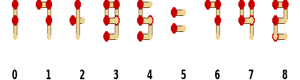

In [4]:
# Move a matchstick
action = "('move', [0, 0, 3, 1])"
obs, reward, terminated, truncated, info = env.step(action)
print(f"Action: {action}")
print(f"Equation: {info['equation']}")
print(f"Feedback: {info.get('env_feedback', 'N/A')}")
display(Image.fromarray(obs))

## 4. Test Solver

Initial equation:


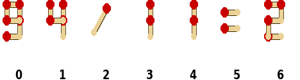


Solver generated 2 actions

Step 1: ('move', [0, 5, 4, 0])
Feedback: Action executed successfully.


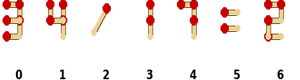


Step 2: ('stop', 'stop')
Feedback: Action executed successfully.


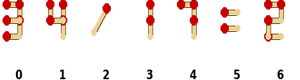


✓ Equation fixed! Reward: 1.0


In [5]:
env = gym.make("matchstick_equation/easy", seed=100)
obs, info = env.reset()
print("Initial equation:")
display(Image.fromarray(obs))

# Get solver actions
actions = env.solve()
print(f"\nSolver generated {len(actions)} actions")

# Execute solver actions
for i, action in enumerate(actions):
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"\nStep {i+1}: {action}")
    print(f"Feedback: {info.get('env_feedback', 'N/A')}")
    display(Image.fromarray(obs))
    if terminated:
        print(f"\n✓ Equation fixed! Reward: {reward}")
        break

env.close()

## 5. Test Hard Difficulty (More Moves Required)

Hard difficulty - 2 break moves allowed (vs easy: 1)


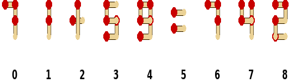


Solution: ["('move', [0, 0, 3, 4])", "('undo', 'undo')", "('move', [4, 1, 1, 0])", "('move', [6, 0, 3, 4])", "('stop', 'stop')"]
Reward: 1.0


In [6]:
env_hard = gym.make("matchstick_equation/hard", seed=42)
obs, info = env_hard.reset()
print(f"Hard difficulty - {env_hard.unwrapped.break_moves} break moves allowed (vs easy: 1)")
display(Image.fromarray(obs))

# Get solution
actions = env_hard.solve()
print(f"\nSolution: {actions}")
for action in actions:
    obs, reward, terminated, truncated, info = env_hard.step(action)
    if terminated:
        print(f"Reward: {reward}")
        break

env_hard.close()